In [12]:
#This code compresses PROCEDURES_ICD9, and DIAGNOSES_ICD9 into single entries per admission (sorted by SEQ_NUM)
#and merges this data with the ADMISSIONS dataframe, providing two separate dataframes with this merged structure.
#One dataframe corresponds to patients diagnosed with specified ICD-9 codes and the other contains the control patients.

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
import shap

ADMISSIONS = pd.read_csv("./ADMISSIONS.csv")
DIAGNOSES_ICD = pd.read_csv("./DIAGNOSES_ICD.csv")
PROCEDURES_ICD = pd.read_csv("./PROCEDURES_ICD.csv")
ICD_9_Filtered = pd.read_csv("./ICD9_GEMINI_ANALYSIS.csv")
ICD_9_DESCRIPTIONS = pd.read_csv("./icd-9-comparison-excel-file.csv")
be_risk_factors = pd.read_csv("./be_risk_factor_codes.csv")

In [13]:
# --- START REPLACEMENT ---
ICD_9_DESCRIPTIONS = ICD_9_DESCRIPTIONS[['ICD9','Description']]

# KEEPING THE SEED: Vital for np.random.choice logic later
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DIAGNOSES_ICD = DIAGNOSES_ICD.dropna(subset=['ICD9_CODE'])
PROCEDURES_ICD = PROCEDURES_ICD.dropna(subset=['ICD9_CODE'])

my_icd9_code = ['4210'] #This is the ICD-9 code for Bacterial Endocarditis, which is the target disease we are trying to predict. 

#Convert ICD9 ints to strings. Not necessary for DIAGNOSES since they contain text as well so interpreted by pandas as string
PROCEDURES_ICD['ICD9_CODE'] = PROCEDURES_ICD['ICD9_CODE'].astype(str).str.zfill(4)

# Merge ICD-9 descriptions into DFs for processing later
DIAGNOSES_ICD = DIAGNOSES_ICD.merge(ICD_9_DESCRIPTIONS, left_on='ICD9_CODE', right_on='ICD9', how='left')
PROCEDURES_ICD = PROCEDURES_ICD.merge(ICD_9_DESCRIPTIONS, left_on='ICD9_CODE', right_on='ICD9', how='left')

#initializing column
DIAGNOSES_ICD['ICD9_FULL'] = DIAGNOSES_ICD['ICD9_CODE']
PROCEDURES_ICD['ICD9_FULL'] = PROCEDURES_ICD['ICD9_CODE']

# 4. Only concatenate where a description actually exists
mask = (DIAGNOSES_ICD['Description'].notna()) & (DIAGNOSES_ICD['Description'] != '')
DIAGNOSES_ICD.loc[mask, 'ICD9_FULL'] = DIAGNOSES_ICD['ICD9_CODE'] + ": " + DIAGNOSES_ICD['Description']

# 4. Only concatenate where a description actually exists
mask2 = (PROCEDURES_ICD['Description'].notna()) & (PROCEDURES_ICD['Description'] != '')
PROCEDURES_ICD.loc[mask2, 'ICD9_FULL'] = PROCEDURES_ICD['ICD9_CODE'] + ": " + PROCEDURES_ICD['Description']

# Keep only the combined column to prevent data leakage
DIAGNOSES_ICD = DIAGNOSES_ICD.drop(columns=['ICD9', 'Description'])
PROCEDURES_ICD = PROCEDURES_ICD.drop(columns=['ICD9', 'Description'])

print(f"Final filtered diagnoses count: {DIAGNOSES_ICD['ICD9_CODE'].nunique()}")
print(f"Final filtered procedures count: {PROCEDURES_ICD['ICD9_CODE'].nunique()}")

#Returns patients with target disease
DISEASE_SUBJECT_ID = DIAGNOSES_ICD.loc[
    DIAGNOSES_ICD["ICD9_CODE"].astype(str).isin(my_icd9_code),
    "SUBJECT_ID"
].unique()

# Also grab patients with target disease in admission text
disease_text_ids = ADMISSIONS[
    ADMISSIONS['DIAGNOSIS'].str.contains('BACTERIAL ENDOCARDITIS', na=False)
]['SUBJECT_ID'].unique()

# Combine both sets — these should ALL be excluded from controls
EXCLUDE_FROM_CONTROLS = np.union1d(DISEASE_SUBJECT_ID, disease_text_ids)

# Now build the entire control group dataset excluding patients with target disease either in text or ICD-9 codes
CONTROL_SUBJECT_ID = DIAGNOSES_ICD.loc[
    ~DIAGNOSES_ICD["SUBJECT_ID"].isin(EXCLUDE_FROM_CONTROLS),
    "SUBJECT_ID"
].unique()

#Returns the specific admissions where target disease was diagnosed
DISEASE_HADM_ID = DIAGNOSES_ICD.loc[
    DIAGNOSES_ICD["ICD9_CODE"].astype(str).isin(my_icd9_code),
    "HADM_ID"
].unique()

#Identify all diagnoses for patients diagnosed with target disease, including for admissions where they were not diagnosed with disease
PATIENT_DIAGNOSES = DIAGNOSES_ICD[DIAGNOSES_ICD['SUBJECT_ID'].isin(DISEASE_SUBJECT_ID)]

#Identify all diagnoses for control patients as well, excluding any with the target disease
CONTROL_DIAGNOSES = DIAGNOSES_ICD[DIAGNOSES_ICD['SUBJECT_ID'].isin(CONTROL_SUBJECT_ID)]

#filter out target diagnosis so that it does not cause data leakage in the ML model, while retaining the patients with the disease
PATIENT_DIAGNOSES = PATIENT_DIAGNOSES[
    ~PATIENT_DIAGNOSES['ICD9_CODE'].isin(my_icd9_code)
]

#Return a new dataframe with all the ICD9 codes for each admission condensed into a single row,col val as a compressed list
# For Diagnoses (Update both Patient and Control blocks)

PATIENT_DIAGNOSES = (
    PATIENT_DIAGNOSES
    .sort_values(['HADM_ID','SEQ_NUM'])
    .groupby(['SUBJECT_ID','HADM_ID'])['ICD9_FULL']
    .apply(list)
    .reset_index(name='DIAGNOSES')
)

#Return a new dataframe with all the ICD9 codes for each admission condensed into a single row,col val as a compressed list for control patients
CONTROL_DIAGNOSES = (
    CONTROL_DIAGNOSES
    .sort_values(['HADM_ID','SEQ_NUM'])
    .groupby(['SUBJECT_ID','HADM_ID'])['ICD9_FULL']
    .apply(list)
    .reset_index(name='DIAGNOSES')
)

#Return all procedures for patients diagnosed with AD, including for admissions where they were not diagnosed with AD
PATIENT_PROCEDURES = PROCEDURES_ICD[PROCEDURES_ICD['SUBJECT_ID'].isin(DISEASE_SUBJECT_ID)]

#identify all procedures for control patients as well
CONTROL_PROCEDURES = PROCEDURES_ICD[PROCEDURES_ICD['SUBJECT_ID'].isin(CONTROL_SUBJECT_ID)]

#Return a new dataframe with all procedure codes for each admission compressed into a single row,col val as a compressed list
PATIENT_PROCEDURES = (
    PATIENT_PROCEDURES
    .sort_values(['HADM_ID','SEQ_NUM'])
    .groupby(['SUBJECT_ID','HADM_ID'])['ICD9_FULL']
    .apply(list)
    .reset_index(name='PROCEDURE TYPE')
)

#Return a new dataframe with all procedure codes for each admission compressed into a single row,col val as a compressed list for control patients
CONTROL_PROCEDURES = (
    CONTROL_PROCEDURES
    .sort_values(['HADM_ID','SEQ_NUM'])
    .groupby(['SUBJECT_ID','HADM_ID'])['ICD9_FULL']
    .apply(list)
    .reset_index(name='PROCEDURE TYPE')
)

#Return every admission entry for patients who were diagnosed with target disease at some point
PATIENT_ADMISSIONS = ADMISSIONS[ADMISSIONS['SUBJECT_ID'].isin(DISEASE_SUBJECT_ID)]

#pull control group admissions as well
CONTROL_ADMISSIONS = ADMISSIONS[ADMISSIONS['SUBJECT_ID'].isin(CONTROL_SUBJECT_ID)]

#Merge the compressed DFs engineered earlier with admissions so that each admission has diagnosis, and procedure data
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS.merge(PATIENT_DIAGNOSES, on=["HADM_ID","SUBJECT_ID"], how="left") \
            .merge(PATIENT_PROCEDURES, on=["HADM_ID","SUBJECT_ID"], how="left")

CONTROL_ADMISSIONS_MERGED = CONTROL_ADMISSIONS.merge(CONTROL_DIAGNOSES, on=["HADM_ID","SUBJECT_ID"], how="left") \
            .merge(CONTROL_PROCEDURES, on=["HADM_ID","SUBJECT_ID"], how="left")


#Rename columns for clarity since there is a text-based labeling column and the ICD-9 diagnosis column
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED.rename(columns={"DIAGNOSIS": "DIAGNOSIS (LABEL)","DIAGNOSES": "DIAGNOSIS (ICD_9)"})
CONTROL_ADMISSIONS_MERGED = CONTROL_ADMISSIONS_MERGED.rename(columns={"DIAGNOSIS": "DIAGNOSIS (LABEL)","DIAGNOSES": "DIAGNOSIS (ICD_9)"})


#Drop redundant row
PATIENT_ADMISSIONS_MERGED.drop(['ROW_ID'],inplace=True,axis=1)
CONTROL_ADMISSIONS_MERGED.drop(['ROW_ID'],inplace=True,axis=1)

#Identify the admissions where target disease was one of the diagnoses given to the patients, excluding admissions where it was not diagnosed
#No need to do this for control group
DISEASE_ADMISSIONS = PATIENT_ADMISSIONS_MERGED[PATIENT_ADMISSIONS_MERGED['HADM_ID'].isin(DISEASE_HADM_ID)]
DISEASE_ADMISSIONS = DISEASE_ADMISSIONS.copy()

#Convert ADMITTIME to datetime for processing
DISEASE_ADMISSIONS['ADMITTIME'] = pd.to_datetime(DISEASE_ADMISSIONS["ADMITTIME"], errors="coerce")
CONTROL_ADMISSIONS_MERGED['ADMITTIME'] = pd.to_datetime(CONTROL_ADMISSIONS_MERGED["ADMITTIME"], errors="coerce")

#Sort by HADM_ID and ADMITTIME to get a sorted list for processing
DISEASE_ADMISSIONS = DISEASE_ADMISSIONS.sort_values(['HADM_ID','ADMITTIME'])
CONTROL_ADMISSIONS_MERGED = CONTROL_ADMISSIONS_MERGED.sort_values(['HADM_ID','ADMITTIME'])

#Identify the earliest admission time in which patients were diagnosed with target disease
DISEASE_FIRST_ADMISSIONS = DISEASE_ADMISSIONS.groupby('SUBJECT_ID',as_index=False)['ADMITTIME'].min()

#Rename this column to "Comparator" since it will be used for filtering admissions from after the patient was diagnosed with target disease
DISEASE_FIRST_ADMISSIONS = DISEASE_FIRST_ADMISSIONS.rename(columns={"ADMITTIME": "Comparator"})

#Update ADMISSIONS_MERGED so it now contains all admissions for patients who were diagnosed with target disease at some point
#Prior and including the admission with their first diagnosis of AD. Admissions after their first diagnosis are excluded
PATIENT_ADMISSIONS_MERGED['ADMITTIME'] = pd.to_datetime(PATIENT_ADMISSIONS_MERGED["ADMITTIME"], errors="coerce")
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED.merge(DISEASE_FIRST_ADMISSIONS,on='SUBJECT_ID',how="left")
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED[PATIENT_ADMISSIONS_MERGED['ADMITTIME']<PATIENT_ADMISSIONS_MERGED['Comparator']]

#drop the comparator column now that filtering is done so that the DFs are the same
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED.drop(['Comparator'],axis=1)

# Ensure data is sorted by patient, with most recent Admission first
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED.sort_values(['SUBJECT_ID', 'ADMITTIME'], ascending=[True, False])

# Count down starting from most recent admission prior to admission of first diagnosis
PATIENT_ADMISSIONS_MERGED['event_index'] = (PATIENT_ADMISSIONS_MERGED.groupby('SUBJECT_ID').cumcount() + 1) * -1

# Number of admissions captured for each patient prior to admission of diagnosis. We are extracting this so we can impute the same distribution into the control group. 
# We do not want the model to learn based on differences in this column between the two groups. We also want the controls group not to have a different number of procedures and diagnoses columns
# which will be further demonstrated in the next pre processing code snippet. This is a critical step to ensure that the model learns based on the content of the admissions and not based on differences in the number of admissions captured for each group, which would be a form of data leakage.
disease_counts = PATIENT_ADMISSIONS_MERGED.groupby('SUBJECT_ID').size()

# Extract all of the unique SUBJECT_IDs within our new controls DF
unique_controls = CONTROL_ADMISSIONS_MERGED['SUBJECT_ID'].unique()

#Randomly sample from distribution of admission count for each patient in disease group, so we can assign for control group patients. This ensures that the admissions index distribution will not differ between disease and controls.
sampled_depths = disease_counts.sample(len(unique_controls), random_state=RANDOM_SEED,replace=True).values

#Assign a theoretical "admissions index" to each control patient based on patients admissions index distribution
depth_map = pd.Series(sampled_depths, index=unique_controls)

# Sort the control admissions by SUBJECT_ID and ADMITTIME to ensure alignment prior to calculating cumulative count for event_index assignment
CONTROL_ADMISSIONS_MERGED = CONTROL_ADMISSIONS_MERGED.sort_values(['SUBJECT_ID', 'ADMITTIME'], ascending=[True, False])

# Compute the number of admissions for each control patient and assign temporary rank to each admission
CONTROL_ADMISSIONS_MERGED['temp_rank'] = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID').cumcount()

# Only keep the most recent n admissions for each control patient, where n is the number of sampled admissions for a diseased patient with the same distribution.
CONTROL_ADMISSIONS_MERGED = CONTROL_ADMISSIONS_MERGED[
    CONTROL_ADMISSIONS_MERGED['temp_rank'] < CONTROL_ADMISSIONS_MERGED['SUBJECT_ID'].map(depth_map)
].copy()

# Compute this hypothetical "admissions index" for controls, with same distribution as patients, assigning to event_index column to ensure a homogenous distribution
CONTROL_ADMISSIONS_MERGED['event_index'] = (CONTROL_ADMISSIONS_MERGED['temp_rank'] + 1) * -1
CONTROL_ADMISSIONS_MERGED.drop(columns=['temp_rank'], inplace=True)

Final filtered diagnoses count: 6984
Final filtered procedures count: 2009


In [14]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import MultiLabelBinarizer

# This function extracts the length of stay for patients, which will be one of the supporting features for the model. It also drops noisy columns that could cause data leakage, such as HADM_ID, ADMITTIME, DISCHTIME, DEATHTIME, EDREGTIME, EDOUTTIME, HOSPITAL_EXPIRE_FLAG, and the text-based diagnosis label since we have the ICD-9 diagnosis codes. This function is applied to both the patients and control dataframes to ensure they have the same structure and features for modeling.
def preprocess_clinical_data(df):
    df = df.copy()
    
    # Calculate length of stay in days
    df['ADMITTIME'] = pd.to_datetime(df['ADMITTIME'])
    df['DISCHTIME'] = pd.to_datetime(df['DISCHTIME'])
    df['LOS_DAYS'] = round((df['DISCHTIME'] - df['ADMITTIME']).dt.total_seconds() / 86400)
    
    # Define Leaky/Identifier columns to drop
    cols_to_drop = [
        'HADM_ID', 'ADMITTIME', 'DISCHTIME', 
        'DEATHTIME', 'EDREGTIME', 'EDOUTTIME', 'HOSPITAL_EXPIRE_FLAG',
        'DIAGNOSIS (LABEL)' # Text label is redundant to ICD9 codes
    ]
    
    # Drop columns if they exist in the dataframe
    existing_drops = [c for c in cols_to_drop if c in df.columns]
    df_clean = df.drop(columns=existing_drops)
    
    return df_clean

# Executing on both, cleaning data
PATIENT_CLEAN = preprocess_clinical_data(PATIENT_ADMISSIONS_MERGED)
CONTROL_CLEAN = preprocess_clinical_data(CONTROL_ADMISSIONS_MERGED)

In [15]:
def prepare_patient_level_features(PATIENT_CLEAN, CONTROL_CLEAN):

    from collections import Counter

    # Combine everything into one DF to ensure columns align across all patients
    df = pd.concat([PATIENT_CLEAN, CONTROL_CLEAN], axis=0)

    # This function extracts the codes from the condensed ICD-9 codes columns per admission, and then returns a list of column labels accounting for both the event index of the row and the ICD9 codes.
    # This allows us to retain temporal structure by assigning codes from each admission to one of the "admission slots" based on event index, which is critical for the model to learn temporal patterns
    def prefix_codes(row, col_name):
        codes = row[col_name]
        if not isinstance(codes, list): return []
        # event_index is -1, -2, etc. We use int() to keep it clean.
        return [f"T{int(row['event_index'])} {code}" for code in codes]

    # This code generates new lists for each admission's diagnoses and procedures, expanding the dataframe horizontally and preparing for one hot encoding while retaining temporal structure. Each code is prefixed with the time slot (T-1, T-2, etc.) to allow the model to learn temporal patterns in the sequence of diagnoses and procedures.
    df['diag_temporal'] = df.apply(lambda x: prefix_codes(x, 'DIAGNOSIS (ICD_9)'), axis=1)
    df['proc_temporal'] = df.apply(lambda x: prefix_codes(x, 'PROCEDURE TYPE'), axis=1)

    # Now we concatenate all the existing diagnoses and procedures temporal codes into single lists per patient, we capture the max length of stay value to capture only the worst severity stay length for each patient to prevent noise
    # Demographic factors remain constant so we will just extract the first value
    patient_df = df.groupby('SUBJECT_ID').agg({
        'diag_temporal': 'sum',
        'proc_temporal': 'sum',
        'LOS_DAYS': 'max',
        'ADMISSION_TYPE': 'first', # Demographics stay the same across visits
        'INSURANCE': 'first',
        'ETHNICITY': 'first'
    }).sort_index()
    

        # 1. Isolate the 74 diseased patients from the combined dataframe
    be_patients_only = patient_df.loc[patient_df.index.isin(DISEASE_SUBJECT_ID)]

    controls_patients_only = patient_df.loc[patient_df.index.isin(CONTROL_SUBJECT_ID)]

    # 2. Flatten all codes into one list (using set() per patient to avoid >100%)
    # This ensures we count 'Patients with the code', not 'Total occurrences'
    all_be_codes = [code for sublist in be_patients_only['diag_temporal'].apply(set) for code in sublist]
    all_controls_codes = [code for sublist in controls_patients_only['diag_temporal'].apply(set) for code in sublist]

    # 3. Count and convert to percentage (N=74)
    be_prevalence = (pd.Series(Counter(all_be_codes))).sort_values(ascending=False)
    controls_prevalence = (pd.Series(Counter(all_controls_codes))).sort_values(ascending=False)

    #Impute any NAs for datetime computed LOS_DAYS with 0s so that model can use this feature without issues. Get dummies is called to one hot encode demographic categories
    X_num = patient_df[['LOS_DAYS']].fillna(0)
    X_cat = pd.get_dummies(patient_df[['ADMISSION_TYPE', 'INSURANCE','ETHNICITY']], dummy_na=True)

    # Manually drop the Newborn column if it exists since newborn status was found to be a top feature. If there are many newborn cases we don't want the model to pick "positive" or "negative" based on this status since newborns are less likely to get bacterial endocarditis
    if 'ADMISSION_TYPE_NEWBORN' in X_cat.columns:
        X_cat = X_cat.drop(columns=['ADMISSION_TYPE_NEWBORN'])    
    return X_num, X_cat, patient_df['diag_temporal'], patient_df['proc_temporal'], patient_df.index, df, be_prevalence, controls_prevalence

# Extract numerical, and categorical features, along with temporal diagnosis and procedure lists for each patient 
num_f, cat_f, diag_list, proc_list, patient_ids, full_df, be_prevalence, controls_prevalence = prepare_patient_level_features(PATIENT_CLEAN, CONTROL_CLEAN)

# Prepare one hot encoding for diagnosis and procedures using MultiLabelBinearizer
mlb_diag = MultiLabelBinarizer(sparse_output=True).fit(diag_list)
mlb_proc = MultiLabelBinarizer(sparse_output=True).fit(proc_list)

# Stack one hot encoded diagnosis and procedure features with numerical and categorical features into a final sparse matrix for modeling.
X_sparse = hstack([
    mlb_diag.transform(diag_list),
    mlb_proc.transform(proc_list),
    csr_matrix(num_f.astype(float)),
    csr_matrix(cat_f.astype(float))
])

# Create target y based on whether a patient is in diseased or controls DF
y = np.array([1 if pid in DISEASE_SUBJECT_ID else 0 for pid in patient_ids])

print(f"New Patient-Level X Shape: {X_sparse.shape}")
print(f"Total Patients: {len(y)} | Diseased Patients: {sum(y)}")

New Patient-Level X Shape: (46254, 16376)
Total Patients: 46254 | Diseased Patients: 73


In [16]:
print("Actual BE Patient Profile:\n", be_prevalence.head(15))

Actual BE Patient Profile:
 T-1 4280: CHF NOS                      33
T-1 42731: Atrial fibrillation         26
T-1 4019: Hypertension NOS             25
T-1 41401: Crnry athrscl natve vssl    20
T-2 42731: Atrial fibrillation         16
T-1 2724: Hyperlipidemia NEC/NOS       13
T-1 5849: Acute kidney failure NOS     12
T-2 40391: Hyp kid NOS w cr kid V      12
T-1 40391: Hyp kid NOS w cr kid V      12
T-1 V5861: Long-term use anticoagul    11
T-2 4280: CHF NOS                      11
T-1 25000: DMII wo cmp nt st uncntr    11
T-1 4241: Aortic valve disorder        11
T-3 42731: Atrial fibrillation         10
T-1 2851: Ac posthemorrhag anemia      10
dtype: int64


In [17]:
print("Controls Patient Profile:\n", controls_prevalence.head(15))

Controls Patient Profile:
 T-1 4019: Hypertension NOS             16111
T-1 42731: Atrial fibrillation          9662
T-1 41401: Crnry athrscl natve vssl     9625
T-1 4280: CHF NOS                       8960
T-1 2724: Hyperlipidemia NEC/NOS        6853
T-1 25000: DMII wo cmp nt st uncntr     6720
T-1 5849: Acute kidney failure NOS      6480
T-1 51881: Acute respiratry failure     5655
T-1 V053: Need prphyl vc vrl hepat      5645
T-1 V290: NB obsrv suspct infect        5432
T-1 53081: Esophageal reflux            4740
T-1 5990: Urin tract infection NOS      4733
T-1 2720: Pure hypercholesterolem       4582
T-1 2859: Anemia NOS                    4037
T-1 2449: Hypothyroidism NOS            3584
dtype: int64


Fold 1 | AUC: 0.783 | Sens: 33.3% | Spec: 95.0%
Fold 2 | AUC: 0.679 | Sens: 40.0% | Spec: 89.0%
Fold 3 | AUC: 0.837 | Sens: 40.0% | Spec: 93.0%
Fold 4 | AUC: 0.757 | Sens: 21.4% | Spec: 92.0%
Fold 5 | AUC: 0.764 | Sens: 35.7% | Spec: 88.0%
Fold 1 | AUC: 0.751 | Sens: 40.0% | Spec: 90.0%
Fold 2 | AUC: 0.833 | Sens: 53.3% | Spec: 92.0%
Fold 3 | AUC: 0.771 | Sens: 40.0% | Spec: 89.0%
Fold 4 | AUC: 0.820 | Sens: 42.9% | Spec: 93.0%
Fold 5 | AUC: 0.704 | Sens: 21.4% | Spec: 94.0%
Fold 1 | AUC: 0.809 | Sens: 40.0% | Spec: 90.0%
Fold 2 | AUC: 0.839 | Sens: 60.0% | Spec: 93.0%
Fold 3 | AUC: 0.695 | Sens: 20.0% | Spec: 97.0%
Fold 4 | AUC: 0.791 | Sens: 42.9% | Spec: 92.0%
Fold 5 | AUC: 0.788 | Sens: 42.9% | Spec: 90.0%
Fold 1 | AUC: 0.854 | Sens: 46.7% | Spec: 90.0%
Fold 2 | AUC: 0.753 | Sens: 26.7% | Spec: 91.0%
Fold 3 | AUC: 0.761 | Sens: 33.3% | Spec: 95.0%
Fold 4 | AUC: 0.815 | Sens: 35.7% | Spec: 92.0%
Fold 5 | AUC: 0.779 | Sens: 21.4% | Spec: 91.0%
Fold 1 | AUC: 0.813 | Sens: 53.3% | Spec

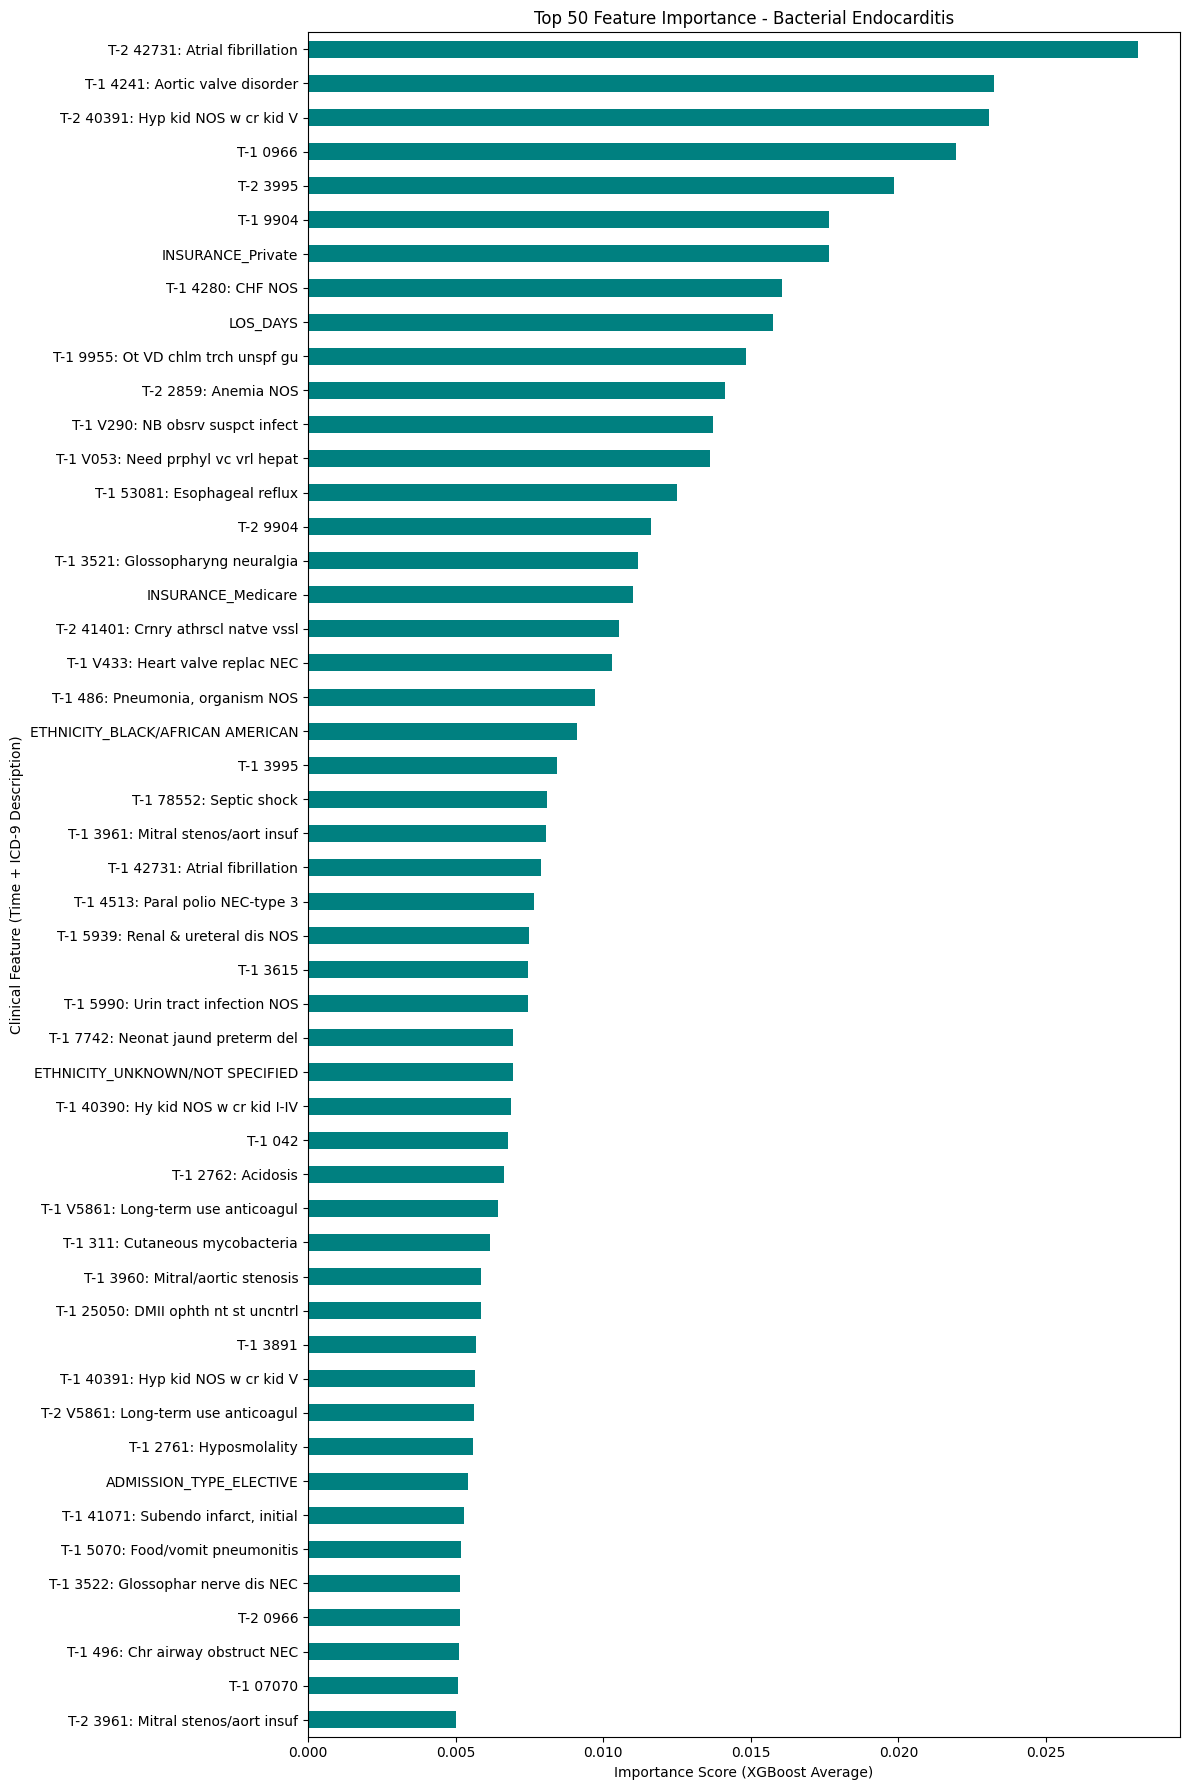

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import shap

all_xgb, all_tree, all_lasso, fold_metrics = [], [], [], []

control_sample_size = 3000 # We will sample 500 controls to mimic real world prevalence of BE
seed_count = round(len(CONTROL_ADMISSIONS_MERGED['SUBJECT_ID'].unique())/control_sample_size)

for seed in range(seed_count):

    rng = np.random.default_rng(seed)
    sampled_control_ids = rng.choice(CONTROL_SUBJECT_ID, size=500, replace=False)

    #setup list of IDs to keep for this iteration, including all diseased patients and randomly sampled controls
    keep_ids = np.concatenate([DISEASE_SUBJECT_ID, sampled_control_ids])
    mask = np.isin(patient_ids, keep_ids)

    X_sparse_seed = X_sparse[mask]
    y_seed = y[mask]

    importances_xgb, importances_tree, importances_lasso = [], [], []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    feat_names = mlb_diag.classes_.tolist() + mlb_proc.classes_.tolist() + ['LOS_DAYS'] + cat_f.columns.tolist()

    scaler = StandardScaler()
    los_idx = feat_names.index('LOS_DAYS')

    all_shap, all_X_te = [], []
    all_shap_lasso = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sparse_seed, y_seed)):

        X_tr, X_te = X_sparse_seed[train_idx], X_sparse_seed[test_idx]
        y_tr, y_te = y_seed[train_idx], y_seed[test_idx]

        ratio = (y_tr == 0).sum() / (y_tr == 1).sum()

        X_tr = X_tr.toarray()
        X_te = X_te.toarray()

        X_tr[:, [los_idx]] = scaler.fit_transform(X_tr[:, [los_idx]])
        # Use transform on test to avoid leakage
        X_te[:, [los_idx]] = scaler.transform(X_te[:, [los_idx]])
        
        ros = RandomOverSampler(random_state=seed,sampling_strategy={1: (y_tr == 0).sum()})
        X_tr, y_tr = ros.fit_resample(X_tr, y_tr)

        # XGBoost
        xgb = XGBClassifier(
            n_estimators=500, 
            learning_rate=0.05, 
            max_depth=3, 
            random_state=seed, # Use the variable
            eval_metric='logloss'
        )
        xgb.fit(X_tr, y_tr)

        explainer = shap.TreeExplainer(xgb)
        all_shap.append(explainer.shap_values(X_te))
        all_X_te.append(X_te)
        
        # Sensitivity and Specificity calculations
        probs = xgb.predict_proba(X_te)[:, 1]
        preds = xgb.predict(X_te)
        auc = roc_auc_score(y_te, probs)
        tn, fp, fn, tp = confusion_matrix(y_te, preds).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        fold_metrics.append({'Seed': seed, 'Fold': fold+1, 'AUC': auc, 'Sens': sens, 'Spec': spec})
        importances_xgb.append(xgb.feature_importances_)
        
        # Decision Tree
        dt = DecisionTreeClassifier(max_depth=5, random_state=42)
        dt.fit(X_tr, y_tr)
        importances_tree.append(dt.feature_importances_)
        
        # Lasso / Logistic Regression
        # C=0.1 provides the 'Lasso' effect of zeroing out weak features

        # 2. Train the Lasso model
        lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
        lasso.fit(X_tr, y_tr)
        importances_lasso.append(np.abs(lasso.coef_[0]))

        # 3. Use LinearExplainer for Logistic Regression
        # We pass X_tr as the background data to help SHAP calculate the base value
        explainer_lasso = shap.LinearExplainer(lasso, X_tr)

        # 4. Calculate and store SHAP values for the test fold
        # For binary Logistic Regression, SHAP returns a single array of values
        shap_values_lasso = explainer_lasso.shap_values(X_te)
        all_shap_lasso.append(shap_values_lasso)
        
        print(f"Fold {fold+1} | AUC: {auc:.3f} | Sens: {sens:.1%} | Spec: {spec:.1%}")

    all_xgb.append(np.mean(importances_xgb, axis=0))
    all_tree.append(np.mean(importances_tree, axis=0))
    all_lasso.append(np.mean(importances_lasso, axis=0))
    

# Results Aggregation
print("\n--- FINAL MEAN METRICS (XGBoost) ---")
print(pd.DataFrame(fold_metrics)[['AUC', 'Sens', 'Spec']].mean())

# Average the importances across folds
master_feat_df = pd.DataFrame({
    'Feature': feat_names,
    'XGBoost': np.mean(all_xgb, axis=0),
    'DecisionTree': np.mean(all_tree, axis=0),
    'Lasso': np.mean(all_lasso, axis=0)
})

# TOP 50 VISUALIZATION
top_50 = master_feat_df.sort_values('XGBoost', ascending=False).head(50)

plt.figure(figsize=(12, 18))
top_50.set_index('Feature')['XGBoost'].sort_values().plot(kind='barh', color='teal')
plt.title('Top 50 Feature Importance - Bacterial Endocarditis')
plt.xlabel('Importance Score (XGBoost Average)')
plt.ylabel('Clinical Feature (Time + ICD-9 Description)')
plt.tight_layout()
plt.show()

# Saving top 50 list
top_50.to_csv('top_50_features_assignment.csv', index=False)

In [19]:
CONTROL_ADMISSIONS_MERGED

,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,...,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS (LABEL),HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA,DIAGNOSIS (ICD_9),PROCEDURE TYPE,event_index
210,2,163353,2138-07-17 19:04:00,2138-07-21 15:48:00,NaN,NEWBORN,PHYS REFERRAL/NORMAL DELI,HOME,Private,NaN,...,NaN,ASIAN,NaN,NaN,NEWBORN,0,1,"[V3001: Single lb in-hosp w cs, V053: Need prp...",[9955: Ot VD chlm trch unspf gu],-1
211,3,145834,2101-10-20 19:08:00,2101-10-31 13:58:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,NaN,...,MARRIED,WHITE,2101-10-20 17:09:00,2101-10-20 19:24:00,HYPOTENSION,0,1,"[0389, 78559: Shock w/o trauma NEC, 5849: Acut...","[9604: Poisoning-tetracycline, 9962: Malfun ne...",-1
212,4,185777,2191-03-16 00:28:00,2191-03-23 18:41:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME WITH HOME IV PROVIDR,Private,NaN,...,SINGLE,WHITE,2191-03-15 13:10:00,2191-03-16 01:10:00,"FEVER,DEHYDRATION,FAILURE TO THRIVE",0,1,"[042, 1363: Pneumocystosis, 7994: Cachexia, 27...","[3893, 8872: Amput abv elbow, unilat, 3323]",-1
213,5,178980,2103-02-02 04:31:00,2103-02-04 12:15:00,NaN,NEWBORN,PHYS REFERRAL/NORMAL DELI,HOME,Private,NaN,...,NaN,ASIAN,NaN,NaN,NEWBORN,0,1,"[V3000: Single lb in-hosp w/o cs, V053: Need p...",[9955: Ot VD chlm trch unspf gu],-1
214,6,107064,2175-05-30 07:15:00,2175-06-15 16:00:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,ENGL,...,MARRIED,WHITE,NaN,NaN,CHRONIC RENAL FAILURE/SDA,0,1,"[40391: Hyp kid NOS w cr kid V, 4440, 9972: Su...","[5569: Ulceratve colitis unspcf, 0091, 3957, 3...",-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55769,99985,176670,2181-01-27 02:47:00,2181-02-12 17:05:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Private,ENGL,...,MARRIED,WHITE,2181-01-26 23:35:00,2181-01-27 04:18:00,FEVER,0,1,"[0389, 51881: Acute respiratry failure, 48241:...","[9672: Poisoning-paraldehyde, 0966, 3893, 0014...",-1
55770,99991,151118,2184-12-24 08:30:00,2185-01-05 12:15:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME,Private,ENGL,...,MARRIED,WHITE,NaN,NaN,DIVERTICULITIS/SDA,0,1,"[56211: Dvrtcli colon w/o hmrhg, 0389, 5570: A...","[1736, 5412: Herpetic ulcer of vulva, 5459, 05...",-1
55771,99992,197084,2144-07-25 18:03:00,2144-07-28 17:56:00,NaN,EMERGENCY,CLINIC REFERRAL/PREMATURE,SNF,Medicare,ENGL,...,WIDOWED,WHITE,2144-07-25 13:40:00,2144-07-25 18:50:00,RETROPERITONEAL HEMORRHAGE,0,1,"[9999: Complic med care NEC/NOS, 56881: Hemope...","[3979: Rheum endocarditis NOS, 8847]",-1
55899,99995,137810,2147-02-08 08:00:00,2147-02-11 13:15:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME,Medicare,ENGL,...,MARRIED,WHITE,NaN,NaN,ABDOMINAL AORTIC ANEURYSM/SDA,0,1,"[4414: Abdom aortic aneurysm, 42833: Ac on chr...","[3971: Rheum pulmon valve dis, 8339, 1771]",-1


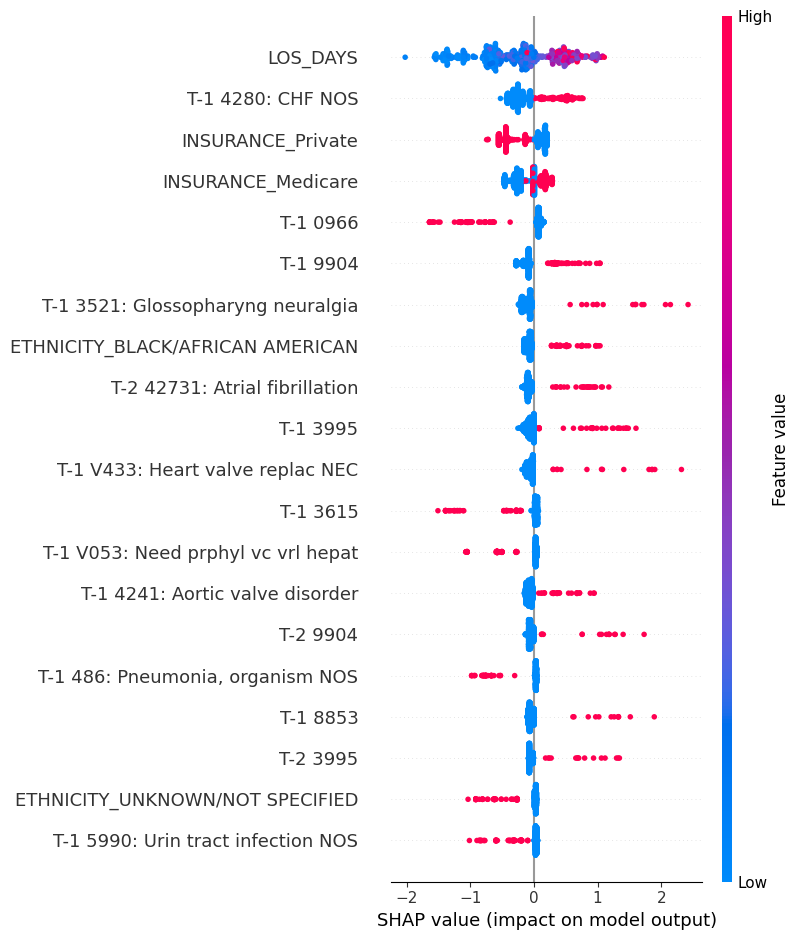

In [20]:
shap.summary_plot(np.vstack(all_shap), np.vstack(all_X_te), feature_names=feat_names)

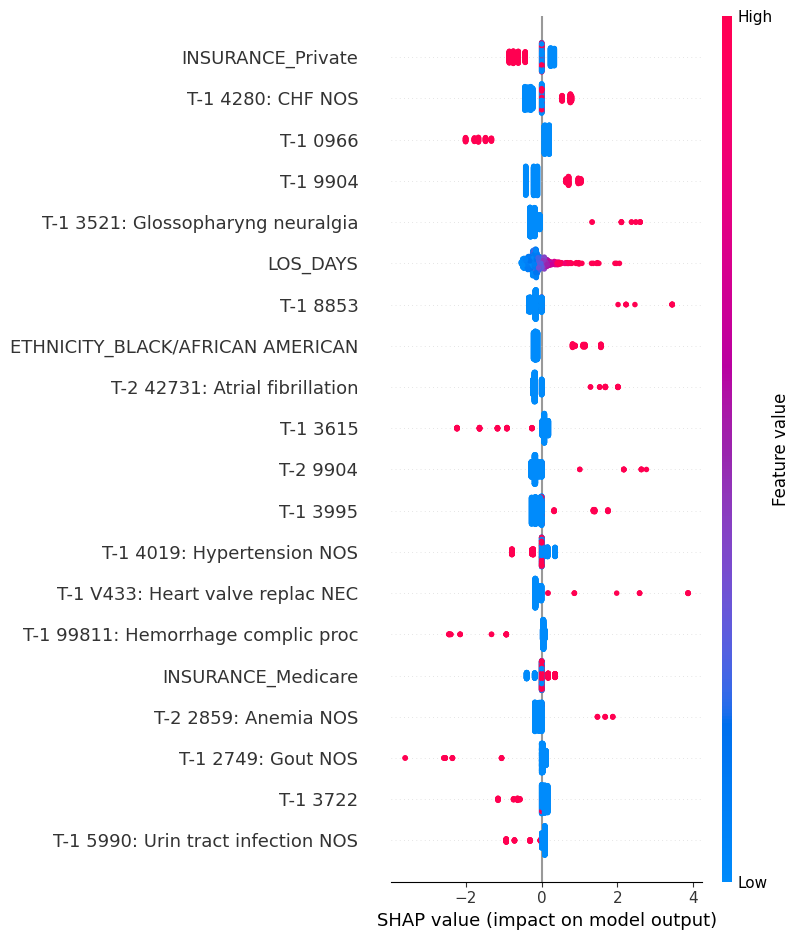

In [21]:
combined_shap_lasso = np.vstack(all_shap_lasso)
combined_X_te = np.vstack(all_X_te)

shap.summary_plot(combined_shap_lasso, combined_X_te, feature_names=feat_names)

In [22]:
# Check for AFib (42731) at T-1 using substring matching
afib_code = '42731'

# Isolate T-1 admissions for patients
pt_t1 = PATIENT_CLEAN[PATIENT_CLEAN['event_index'] == -1]

# Search for the code within any string in the list
has_afib = pt_t1['DIAGNOSIS (ICD_9)'].apply(
    lambda x: any(afib_code in item for item in x) if isinstance(x, list) else False
)

print(f"Total patients with a T-1 admission: {len(pt_t1)}")
print(f"Patients with AFib (42731) at T-1: {has_afib.sum()}")

Total patients with a T-1 admission: 73
Patients with AFib (42731) at T-1: 26
